**Environment Setup**

تهيئة بيئة العمل


In [1]:
!pip install pandas numpy sklearn matplotlib seaborn
!pip install arabert
!pip install transformers
!pip install torch

  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.0/185.0 kB 9.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 8.8 MB/s eta 0:00:00
  Created wheel for emoji: filename=emoji-1.4.2-py3-none-any.whl size=186456 sha256=77d14c732bd7a30229c25146a771687408fb57bef585471ccc7487c38df37448
  Stored in directory: /root/.cache/pip/wheels/bb/f1/26/f9002669ef6ad80a3c9f1b22880b35d9b4c6650011acee0523
Successfully built emoji
  Attempting uninstall: emoji
  

**Download and view dataset**

تحميل البيانات واستعراضها 

In [2]:
import pandas as pd

df = pd.read_csv("/kaggle/input/330k-arabic-sentiment-reviews/arabic_sentiment_reviews.csv")
df.head(10)

,label,content
0,1,النعال المريحة: أرتدي هذه النعال كثيرًا!فهي دا...
1,1,منتج جميل ، خدمة سيئة: لقد اشتريت زوجًا من الن...
2,1,جيد للأشياء الصغيرة: هذا يعمل بشكل جيد لالتقاط...
3,0,واهية للغاية: flimsyif للغاية ، فأنت تشتريه ، ...
4,1,Pop for Girls and Girly Boys ، والأشخاص الذين ...
5,1,تم الوفاء بالذكريات: شكرًا على تزويدني بشيء اع...
6,1,Love to Love Book of Love: Book of Love هو أحد...
7,1,كريستين ، الملاك!: هذا الكتاب هائل!المعلومات ل...
8,1,The Everest of Musical Theatre: اليوم ، يُشار ...
9,0,عار: لقد شعرت بخيبة أمل لأنه رائحة الدخان وكان...


**Exploratory Data Analysis**

In [3]:
df.tail()

,label,content
329995,0,DOA: فتح العلامة التجارية الجديدة من Box.تم تث...
329996,0,شركة صعبة التعامل معها: المنتج كان على ما يرام...
329997,0,SDK Sansa Leather Case: فقير للغاية.لم يتم الإ...
329998,0,حسنًا ، لكن ليس رائعًا: حسنًا ، لقد اشتريت هذا...
329999,1,مريحة جدا!: هذه النعال رائعة!أنها ناعمة جدا وم...


In [4]:
df.describe()

,label
count,330000.000000
mean,0.505615
std,0.499969
min,0.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,1.000000


In [5]:
#check mising value 
df.isnull().sum()

label      0
content    0
dtype: int64

In [6]:
df.sample(5)

,label,content
178795,1,فيلم رائع ، ولكن ليس للأطفال: أوصي بهذا الفيلم...
10309,0,لا تبقي قهوتي ساخنة: قررت أن أستبدل أكثر دفئًا...
163339,0,من فضلك ، تجنب نفسك العذاب: أتمنى أن أعطي هذا ...
154277,1,فيلم رائع ولكن التنسيق رديء: لماذا لا يصنع الا...
162049,0,لا قيمة لها: كنت متحمسًا لشراء هذا الكتاب ، لأ...


In [7]:
print(df.shape)
print(df.columns)
print(df['label'].value_counts())

(330000, 2)
Index(['label', 'content'], dtype='object')
label
1    166853
0    163147
Name: count, dtype: int64


In [8]:
df['text_length'] = df['content'].apply(len)
df['text_length'].describe()

count    330000.000000
mean        362.388658
std         197.916663
min           2.000000
25%         196.000000
50%         325.000000
75%         499.000000
max        1035.000000
Name: text_length, dtype: float64

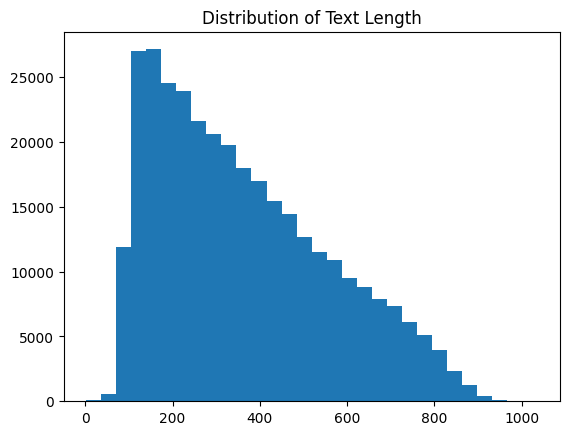

In [9]:
import matplotlib.pyplot as plt

plt.hist(df['text_length'], bins=30)
plt.title("Distribution of Text Length")
plt.show()

In [10]:
df.duplicated().sum()

np.int64(32)

In [11]:
df = df.drop_duplicates()

In [12]:
from collections import Counter
import re

all_text = " ".join(df['content'].astype(str))
words = re.findall(r'\w+', all_text)
counter = Counter(words)
counter.most_common(10)


[('من', 659680),
 ('ا', 576132),
 ('في', 531559),
 ('هذا', 407037),
 ('على', 379540),
 ('أن', 323628),
 ('لا', 244569),
 ('إلى', 192070),
 ('كان', 153339),
 ('الكتاب', 133911)]

In [13]:
df['label'].value_counts()


label
1    166844
0    163124
Name: count, dtype: int64

In [14]:
df['has_english'] = df['content'].apply(lambda x: bool(re.search(r'[a-zA-Z]', str(x))))
df['has_english'].value_counts()


has_english
True     193272
False    136696
Name: count, dtype: int64

**Clean Data**

In [15]:
import re
def clean_text(text):
    # Convert to string
    text = str(text)
    # Remove English words
    text = re.sub(r'[a-zA-Z]+', ' ', text)
    # Remove numbers
    text = re.sub(r'\d+', ' ', text)
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', ' ', text)
    # Remove punctuation and symbols
    text = re.sub(r'[^\w\s]', ' ', text)
    # Remove repeated characters (example: رائــــع → رائع)
    text = re.sub(r'(.)\1{2,}', r'\1', text)
    # Remove Arabic diacritics 
    text = re.sub(r'[\u0617-\u061A\u064B-\u0652]', '', text)
    # Convert to lowercase
    text = text.lower()
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text
# Example
texts = [
"أرتدي هذه النعال كثيرًا!فهي دافئة ومريحة وبأسعار معقولة لجودة رائعة.زوجي وأنا على حد...",
"منتج جميل ، خدمة سيئة: لقد اشتريت زوجًا من النعال الباو الدب.باتباع إرشادات وصف المنتج ، ارتفعت حجمً...",
"Pop for Girls and Girly Boys ، والأشخاص الذين يحبون الضحك: عليك فقط أن تبتسم عندما تستمع إلى Book of..."
]
cleaned = [clean_text(t) for t in texts]
print(cleaned)

['أرتدي هذه النعال كثير ا فهي دافئة ومريحة وبأسعار معقولة لجودة رائعة زوجي وأنا على حد', 'منتج جميل خدمة سيئة لقد اشتريت زوج ا من النعال الباو الدب باتباع إرشادات وصف المنتج ارتفعت حجم', 'والأشخاص الذين يحبون الضحك عليك فقط أن تبتسم عندما تستمع إلى']


In [16]:
df['clean_text'] = df['content'].apply(clean_text)

**Train–Test Split**

تقسيم البيانات إلى تدريب واختبار 

In [20]:
from sklearn.model_selection import train_test_split

X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Text Vectorization using TF-IDF**


تحويل النصوص إلى أرقام 

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords

arabic_stopwords = stopwords.words("arabic")

vectorizer = TfidfVectorizer(stop_words=arabic_stopwords, max_features=10000)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)


/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['آمين', 'أب', 'أخ', 'أفعل', 'أفعله', 'ؤلاء', 'إل', 'إم', 'ات', 'اتان', 'ارتد', 'ان', 'انفك', 'برح', 'تان', 'تبد', 'تحو', 'تعل', 'حد', 'حم', 'حي', 'خب', 'ذار', 'سيما', 'صه', 'ظل', 'ظن', 'عد', 'قط', 'مر', 'مكان', 'مكانكن', 'نب', 'هات', 'هب', 'واها', 'وراء'] not in stop_words.
  warnings.warn(


**Training Logistic Regression Model**


تدريب نموذج الانحدار اللوجستي 

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)


LogisticRegression(max_iter=1000)

In [28]:
train_pred = model.predict(X_train_tfidf)
train_acc = accuracy_score(y_train, train_pred)
print("Train Accuracy:", train_acc)


Train Accuracy: 0.8918719267806678


**Model Evaluation**


تقييم النموذج 


In [29]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.8802012304148862
              precision    recall  f1-score   support

           0       0.88      0.87      0.88     32583
           1       0.88      0.89      0.88     33411

    accuracy                           0.88     65994
   macro avg       0.88      0.88      0.88     65994
weighted avg       0.88      0.88      0.88     65994



[[28409  4174]
 [ 3732 29679]]


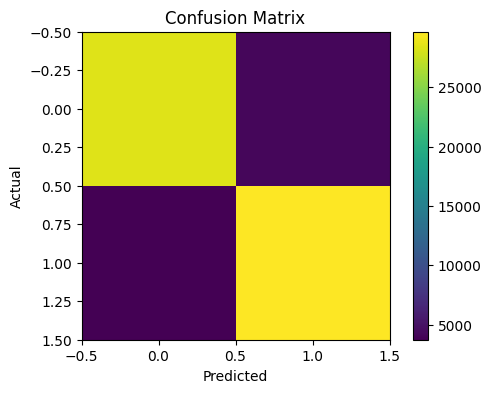

In [30]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
print(cm)

plt.figure(figsize=(6,4))
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()


**Test**

In [32]:
def predict_sentiment(text):
    cleaned = clean_text(text)
    vec = vectorizer.transform([cleaned])
    pred = model.predict(vec)[0]
    return "إيجابي" if pred == 1 else "سلبي"


In [33]:
# Test 1
text = "هذا المنتج, ممتاز جدًا وسهل الاستخدام"
print(predict_sentiment(text))


إيجابي


In [34]:
# Test 2
text = "!!!!سيئ جدا"
print(predict_sentiment(text))


سلبي


**Prediction with Probability**

In [36]:
def predict_sentiment_prob(text):
    cleaned = clean_text(text)
    vec = vectorizer.transform([cleaned])
    
    prob = model.predict_proba(vec)[0]
    pred = model.predict(vec)[0]
    
    return pred, prob

In [37]:
text = "هذا المنتج ممتاز جدًا وسهل الاستخدام"
pred, prob = predict_sentiment_prob(text)

print("Prediction:", "إيجابي" if pred==1 else "سلبي")
print("Probability:", prob)


Prediction: إيجابي
Probability: [0.00214468 0.99785532]


In [38]:
text = "هصعب"
pred, prob = predict_sentiment_prob(text)

print("Prediction:", "إيجابي" if pred==1 else "سلبي")
print("Probability:", prob)

Prediction: سلبي
Probability: [0.53378878 0.46621122]


**Hyperparameter Tuning**

تحسين المودل

In [39]:
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# TF-IDF
arabic_stopwords = stopwords.words("arabic")

vectorizer = TfidfVectorizer(
    stop_words=arabic_stopwords,   
    max_features=20000,
    ngram_range=(1,2)
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Hyperparameter Tuning
params = {
    'C': [0.01, 0.1, 1, 10],
    'max_iter': [1000, 2000],
    'solver': ['liblinear', 'lbfgs']
}

grid = GridSearchCV(
    LogisticRegression(),
    params,
    cv=3,
    scoring='accuracy',
    n_jobs=1   
)

grid.fit(X_train_tfidf, y_train)

best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)
print("Best Score (CV):", grid.best_score_)

# Evaluation
y_pred = best_model.predict(X_test_tfidf)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['آمين', 'أب', 'أخ', 'أفعل', 'أفعله', 'ؤلاء', 'إل', 'إم', 'ات', 'اتان', 'ارتد', 'ان', 'انفك', 'برح', 'تان', 'تبد', 'تحو', 'تعل', 'حد', 'حم', 'حي', 'خب', 'ذار', 'سيما', 'صه', 'ظل', 'ظن', 'عد', 'قط', 'مر', 'مكان', 'مكانكن', 'نب', 'هات', 'هب', 'واها', 'وراء'] not in stop_words.
  warnings.warn(


Best Parameters: {'C': 1, 'max_iter': 1000, 'solver': 'liblinear'}
Best Score (CV): 0.8904930067263989
Test Accuracy: 0.8946419371458011
              precision    recall  f1-score   support

           0       0.90      0.89      0.89     32583
           1       0.89      0.90      0.90     33411

    accuracy                           0.89     65994
   macro avg       0.89      0.89      0.89     65994
weighted avg       0.89      0.89      0.89     65994



In [40]:
# Train Accuracy
train_pred = best_model.predict(X_train_tfidf)
train_acc = accuracy_score(y_train, train_pred)
print("Train Accuracy:", train_acc)

# Test Accuracy
test_pred = best_model.predict(X_test_tfidf)
test_acc = accuracy_score(y_test, test_pred)
print("Test Accuracy:", test_acc)


Train Accuracy: 0.9101009947949419
Test Accuracy: 0.8946419371458011


In [41]:
def predict_sentiment(text):
    cleaned = clean_text(text)
    vec = vectorizer.transform([cleaned])
    pred = best_model.predict(vec)[0]
    return "إيجابي" if pred == 1 else "سلبي"


text = " المنتج ليس كما توقعت "
print(predict_sentiment(text))


سلبي
